In [14]:
import pandas as pd
df = pd.read_csv('Amazon.csv')
df.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [15]:
df.shape

(100000, 20)

In [16]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

## Data Checking - Data Preparation - Data Cleaning

In [17]:
df.dtypes

OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object

In [18]:
# Order date is currently an object, we need to convert it to datetime format for easier analysis.

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['MonthYear'] = df['OrderDate'].dt.to_period('M') # Creating a monthly cohort

In [19]:
df['MonthYear'].head()

0    2023-01
1    2023-12
2    2022-05
3    2023-07
4    2023-02
Name: MonthYear, dtype: period[M]

In [23]:
# We need new columns for revenue and order status to calculate key metrics.

total_revenue = df['TotalAmount'].sum()
avg_order_value = df['TotalAmount'].mean()
cancellation_rate = (df['OrderStatus'] == 'Cancelled').mean() * 100

In [ ]:
# Analyse performance by category and country.

category_perf = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
country_perf = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)

C:\Users\Dan\AppData\Local\Temp\ipykernel_2248\1781278226.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], x=brand_sales.values, y=brand_sales.index, palette='magma')


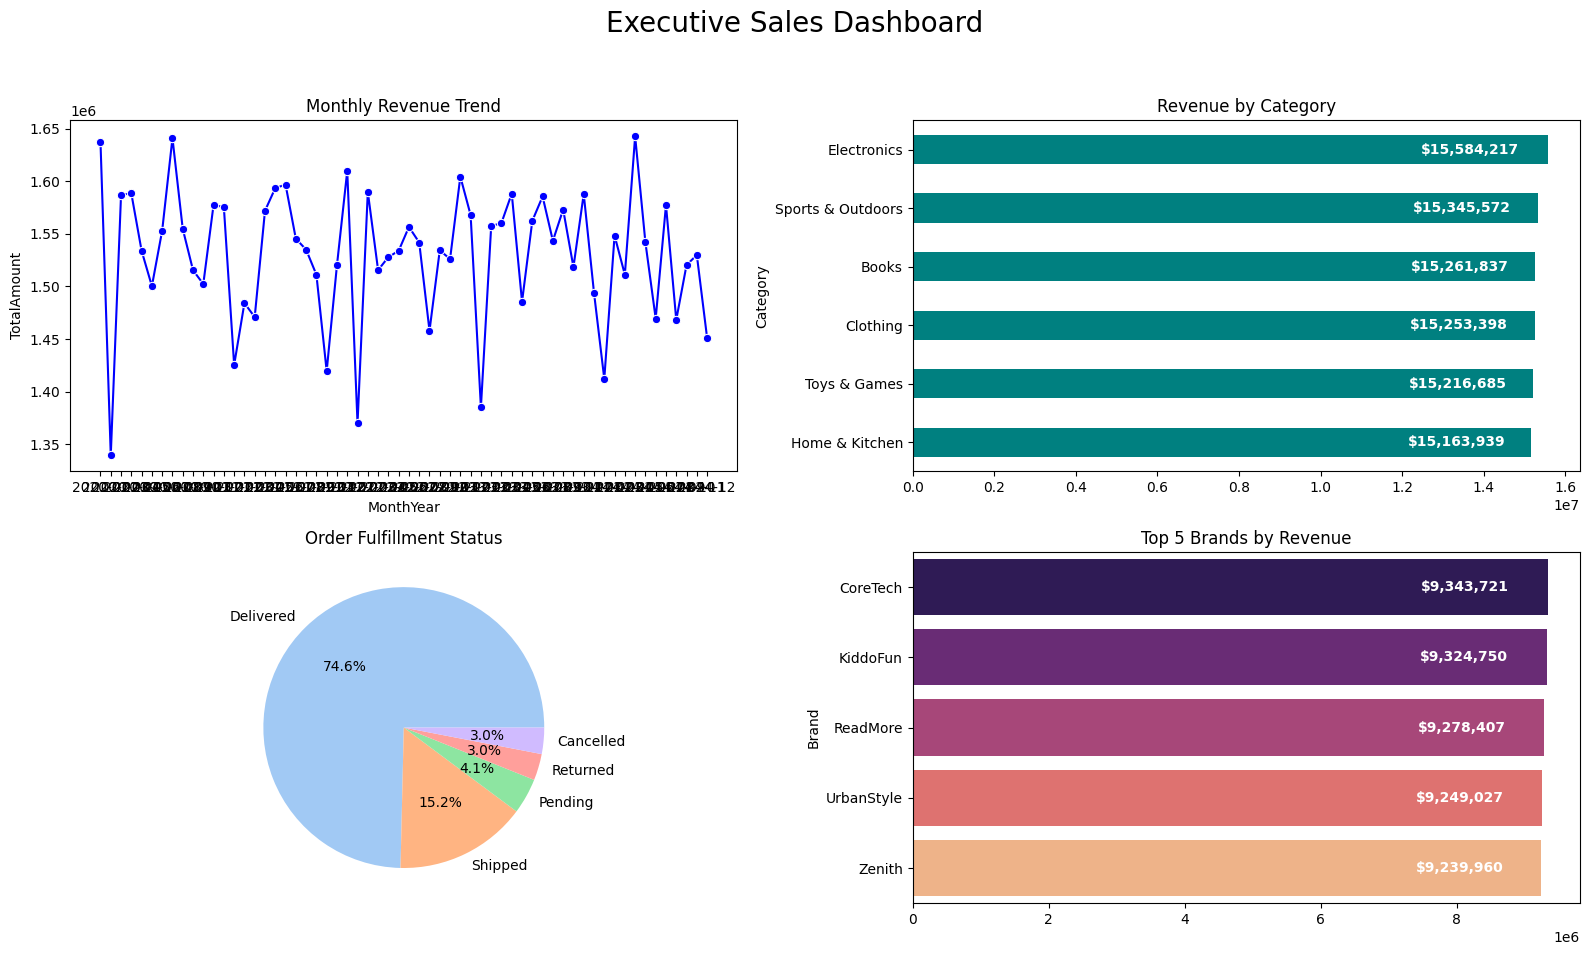

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the figure grid (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Executive Sales Dashboard', fontsize=20)

# 2. Top Left: Monthly Trend (Line Chart)
monthly_sales = df.groupby('MonthYear')['TotalAmount'].sum().reset_index()
monthly_sales['MonthYear'] = monthly_sales['MonthYear'].astype(str)
sns.lineplot(ax=axes[0, 0], data=monthly_sales, x='MonthYear', y='TotalAmount', marker='o', color='b')
axes[0, 0].set_title('Monthly Revenue Trend')

# 3. Top Right: Category Performance (Bar Chart)
cat_sales = df.groupby('Category')['TotalAmount'].sum().sort_values()
cat_sales.plot(kind='barh', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Revenue by Category')
for i, (index, value) in enumerate(cat_sales.items()):
    axes[0, 1].text(value * 0.80, i, f'${value:,.0f}', va='center', color='white', fontweight='bold')


# 4. Bottom Left: Order Status (Pie Chart)
status_counts = df['OrderStatus'].value_counts()
axes[1, 0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Order Fulfillment Status')

# 5. Bottom Right: Top Brands (Bar Chart)
brand_sales = df.groupby('Brand')['TotalAmount'].sum().nlargest(5)
sns.barplot(ax=axes[1, 1], x=brand_sales.values, y=brand_sales.index, palette='magma')
axes[1, 1].set_title('Top 5 Brands by Revenue')
for i, (index, value) in enumerate(brand_sales.items()):
    axes[1, 1].text(value * 0.80, i, f'${value:,.0f}', va='center', color='white', fontweight='bold')

# Adjust layout so labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()